In [11]:
%load_ext autoreload
%autoreload 2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torchsummary import summary
from M2.DP import DPForwardSolver
from M2.Utils.source import source
from M2.PINN.model import AcousticPINN, g, PINNForwardSolver
from M2.PINN.loss import loss_fn
from M2.PINN.training import train_pinn
from M2.inverse_problem import inverse_function
from M2.Utils.visualization import check_seismograms

device = "cpu" #"mps"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
sensors = torch.tensor([[-1.0, 0.0],
                        [ 1.0, 0.0]], device="cpu")
true_ex, true_ey = 0.0, 0.0

In [13]:
dp_solver = DPForwardSolver(
    sensors=sensors,
    c=5.0,
    x_min=-40.0, x_max=40.0,
    y_min=-40.0, y_max=40.0,
    Nx=401, Ny=401,
    Nt=750, T=5.0,
    A=100.0,                        # amplitude_g in the notebook
    t0=1.0,                         # Ricker peak time
    f0=1.0,                         # Ricker frequency
    gamma=1.0 / (2.0 * 0.3**2),    # converts sigma=0.3 to your gamma
    device="cpu",
)

seismograms = dp_solver.forward(e_x=true_ex, e_y=true_ey)  # (750, 3)

t_fd = np.linspace(0, 5.0, 750)
fd_seis = {
    '(-1,0)': seismograms[:, 0].detach().cpu().numpy(),
    '(1,0)':  seismograms[:, 1].detach().cpu().numpy(),
}
traces_obs = dp_solver.forward(e_x=true_ex, e_y=true_ey).detach()

In [ ]:

e_hat_dp, traces_dp, _, history_dp = inverse_function(
    forward=dp_solver,
    traces_obs=traces_obs,
    dt=dp_solver.dt,
    init=(1, 1),
    steps=50,
    lr=1,
    max_iter=1,
    device="cpu",
)
history_dp.insert(0, (1, 1))  # add initial guess to history
history_dp = np.array(history_dp)

  0%|          | 0/50 [00:00<?, ?it/s]

array([1.69865228e-03, 9.95326417e-08])

In [15]:
model = AcousticPINN(n_layers=3, layer_width=64).to(device)
summary(model.cpu(), [(1, 1), (1, 1), (1, 1), (1, 1), (1, 1)])
model = model.to(device)

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1, 64]               --
|    └─Linear: 2-1                       [-1, 1, 64]               384
|    └─Tanh: 2-2                         [-1, 1, 64]               --
├─ModuleList: 1                          []                        --
|    └─Sequential: 2-3                   [-1, 1, 64]               --
|    |    └─Linear: 3-1                  [-1, 1, 64]               4,160
|    |    └─Tanh: 3-2                    [-1, 1, 64]               --
|    └─Sequential: 2-4                   [-1, 1, 64]               --
|    |    └─Linear: 3-3                  [-1, 1, 64]               4,160
|    |    └─Tanh: 3-4                    [-1, 1, 64]               --
|    └─Sequential: 2-5                   [-1, 1, 64]               --
|    |    └─Linear: 3-5                  [-1, 1, 64]               4,160
|    |    └─Tanh: 3-6                    [-1, 1, 64]               --
├─Mod

In [16]:
# model = train_pinn(model, fd_seis, t_fd, device=device)
# torch.save(model,"model.pt")
model = torch.load(
    "model_cpu.pt",
    map_location=torch.device("cpu"),
    weights_only=False
)
model.eval()

AcousticPINN(
  (lift): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): Tanh()
  )
  (layers1): ModuleList(
    (0-2): 3 x Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): Tanh()
    )
  )
  (layers2): ModuleList(
    (0-2): 3 x Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): Tanh()
    )
  )
  (compress): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): Tanh()
  )
  (output): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [28]:
pinn_solver = PINNForwardSolver(
    model=model,
    sensors=torch.tensor([[-1.0, 0.0], [1.0, 0.0]]),
    t_max=5.0, n_t=750,
    x_min=-5, x_max=5, y_min=-5, y_max=5,
    device=device,
)

e_hat_pinn, traces_pinn, _, history_pinn = inverse_function(
    forward=pinn_solver,
    traces_obs=pinn_solver.forward(e_x=true_ex, e_y=true_ey).detach()
,
    dt=pinn_solver.dt,
    init=(1.0, 1.0),
    steps=50,
    lr=1,
    max_iter=1,
    device=device,
)
history_pinn.insert(0, (1.0, 1.0))  # add initial guess to history
history_pinn = np.array(history_pinn)

  0%|          | 0/50 [00:00<?, ?it/s]

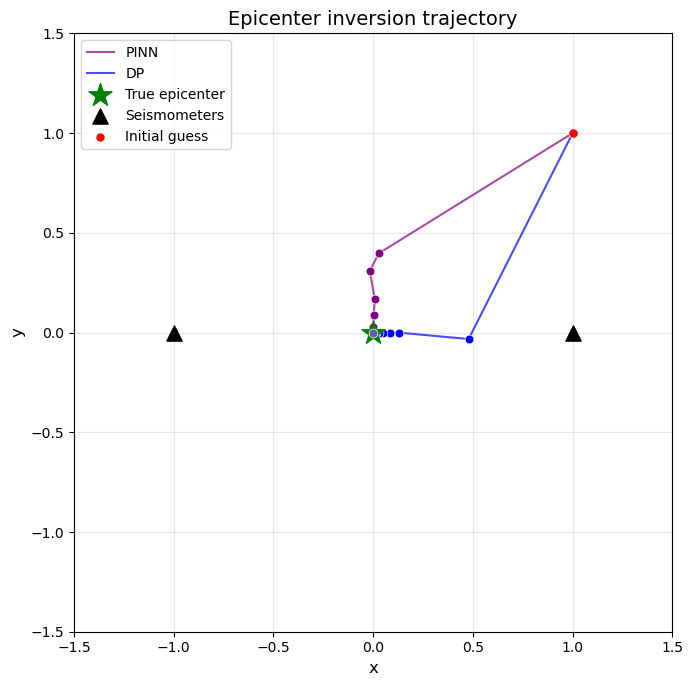

In [32]:
fig, ax = plt.subplots(figsize=(7, 7))

# Trajectory dots (all except last)
ax.scatter(history_pinn[:-1, 0], history_pinn[:-1, 1],
           color='purple', s=40, edgecolors='white',
           linewidths=0.5, zorder=5)
# Trajectory
ax.plot(history_pinn[:, 0], history_pinn[:, 1],
        color='purple', linewidth=1.5, alpha=0.7, zorder=3, label='PINN')

ax.scatter(history_dp[:-1, 0], history_dp[:-1, 1],
           color='blue', s=40, edgecolors='white',
           linewidths=0.5, zorder=5)
# Trajectory
ax.plot(history_dp[:, 0], history_dp[:, 1],
        color='blue', linewidth=1.5, alpha=0.7, zorder=3, label='DP')

# True epicenter
ax.scatter(true_ex, true_ey,
           marker='*', color='green', s=300,
           linewidths=1, zorder=6, label='True epicenter')

# Last trajectory dot on top
ax.scatter(history_pinn[-1, 0], history_pinn[-1, 1],
           color='#5B5EA6', s=40, edgecolors='white',
           linewidths=0.5, zorder=7)
# Sensors
ax.scatter(dp_solver.sensors[:, 0].cpu(),
           dp_solver.sensors[:, 1].cpu(),
           marker='^', color='black', s=120, zorder=5, label='Seismometers')

# Initial guess
ax.scatter(history_pinn[0, 0], history_pinn[0, 1],
           marker='.', facecolors='red', s=100,
           zorder=8, label='Initial guess')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Epicenter inversion trajectory', fontsize=14)
ax.legend(fontsize=10, loc='upper left')
ax.set_aspect('equal')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('inversion_trajectory.pdf', bbox_inches='tight', dpi=300)
plt.show()